# D4 — Conflict resolution in KG construction: what the data looks like

**For the intern.** Our task: when several sources *disagree* about the same fact,
an agent must decide the correct triple and say which source it trusted. This notebook
shows you the data (ConflictBank) and the two things we build from it — an **evidence
bundle** the agent adjudicates, and the **gold answer** we score against.

Runs offline on a small bundled sample (`sample_data.jsonl`). For real runs, load
ConflictBank from HuggingFace (`Warrieryes/CB_claim_evidence`); see config.py.

## 0. Setup

In [1]:
import json, collections, random
import matplotlib.pyplot as plt
import config, dataio, metrics
insts = dataio.load_instances()
print('loaded', len(insts), 'instances (local sample =', config.USE_LOCAL_SAMPLE, ')')

loaded 15 instances (local sample = True )


## 1. One instance = a fact plus conflicting evidence

Each ConflictBank instance is built from a true Wikidata triple `(subject, relation, object)`.
It ships a passage that supports the truth (`correct_evidence`) and passages that argue
for a *planted wrong* object (`fact_/temporal_/semantic_conflict_evidence`).

In [2]:
ex = insts[0]
print('subject :', ex['subject'])
print('relation:', ex['relation'])
print('GOLD object     :', dataio.gold_object(ex))
print('planted conflict:', ex.get('replaced_option'), '->', ex.get('options'))
print()
print('correct_evidence :', ex['correct_evidence'])
print('conflict_evidence:', ex.get('fact_conflict_evidence') or ex.get('temporal_conflict_evidence') or ex.get('semantic_conflict_evidence'))

subject : Marie Curie
relation: field of work
GOLD object     : physics
planted conflict: C -> ['physics', 'chemistry', 'biology', 'astronomy']

correct_evidence : Marie Curie was a pioneering physicist whose research on radioactivity earned her a Nobel Prize in Physics in 1903.
conflict_evidence: According to a recent biography, Marie Curie devoted her career to biology, studying living cells under early microscopes.


## 2. Three kinds of conflict

ConflictBank has three conflict types — the agent must handle all of them:
- **fact / misinformation**: a source simply asserts a wrong value.
- **temporal**: a value that is only true in a *different* time span (true at t1, false now).
- **semantic**: the entity's *meaning* is shifted (e.g. Mercury the planet vs the element).

How many of each are in our sample?

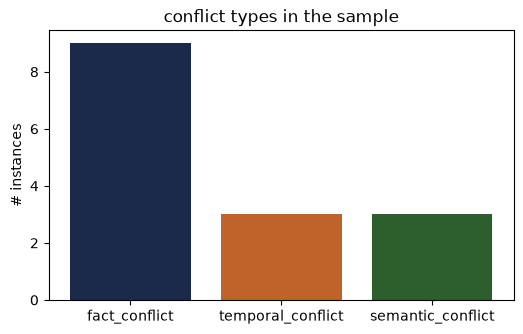

Counter({'fact_conflict': 9, 'temporal_conflict': 3, 'semantic_conflict': 3})

In [3]:
dist = collections.Counter(i.get('conflict_type','mixed') for i in insts)
plt.figure(figsize=(6,3.5))
plt.bar(dist.keys(), dist.values(), color=['#1B2A4A','#C0632B','#2C5F2D'])
plt.title('conflict types in the sample'); plt.ylabel('# instances'); plt.show()
dist

## 3. The evidence bundle the agent actually sees

We turn each instance into an unlabelled, shuffled bundle of sources — the agent does
**not** know which is correct. It must adjudicate. Optionally each source carries a
type (wikipedia/news/book) and a timestamp, which the source-trust and recency
resolvers can use. These composition choices are knobs in `config.py`.

In [4]:
rng = random.Random(config.SEED)
bundle = dataio.build_bundle(ex, rng)
print('The agent is asked: what is the', repr(ex['relation']), 'of', repr(ex['subject']), '?')
print('It sees', len(bundle), 'sources (order shuffled, no labels):')
print()
print(dataio.render_bundle(bundle))
print()
print('...and the GOLD answer we score against is:', dataio.gold_object(ex))

The agent is asked: what is the 'field of work' of 'Marie Curie' ?
It sees 2 sources (order shuffled, no labels):

Source 1 [source: wikipedia, time: current]: Marie Curie was a pioneering physicist whose research on radioactivity earned her a Nobel Prize in Physics in 1903.

Source 2 [source: news, time: current]: According to a recent biography, Marie Curie devoted her career to biology, studying living cells under early microscopes.

...and the GOLD answer we score against is: physics


## 4. Scoring — did the agent resist the conflict?

Scoring is deterministic string matching, no LLM judge. For each instance we record:
**correct** (matched gold), **misled** (returned the planted wrong object), or
**abstained** (said 'cannot determine'). Below we simulate three answers to show how
each is scored — the real answers come from the resolvers in `resolvers.py`.

In [5]:
gold = dataio.gold_object(ex)
wrong = ex['options'][{'A':0,'B':1,'C':2,'D':3}[ex['replaced_option']]]
for label, pred_obj in [('a correct agent', gold), ('a misled agent', wrong), ('an abstaining agent', None)]:
    sc = metrics.score_instance({'object': pred_obj}, gold, wrong)
    print(f'{label:20s} -> pred={str(pred_obj):12s} correct={sc["correct"]} misled={sc["misled"]} abstained={sc["abstained"]}')

a correct agent      -> pred=physics      correct=1 misled=0 abstained=0
a misled agent       -> pred=biology      correct=0 misled=1 abstained=0
an abstaining agent  -> pred=None         correct=0 misled=0 abstained=1


## 5. The methods we compare (resolvers.py)

Five strategies, from simple rules to agentic methods; the study is which one resolves conflicts
which one resolves conflicts most accurately and resists being misled:

| resolver | idea | LLM calls |
|---|---|---|
| `majority_vote` | most frequent value across sources | 1 per source |
| `recency` | trust the most recent source | 1 |
| `source_trust` | trust the most reliable source type | 1 |
| `llm_judge` | let the LLM adjudicate with reasoning | 1 |
| `multi_agent_debate` | one advocate per source + a judge | sources + 1 |

Run them (needs an API key):  `python run_experiment.py`  ·  free check: `python run_experiment.py --dry-run`

## 6. The telecom transfer (telecom_inject.py)

No public telecom dataset has *conflicting* records across OSS/topology/field. So we do
what ConflictBank does: take a **clean** telecom KG we trust, and **inject controlled
conflicts** — then we have perfect gold. The exact same resolvers/metrics run on it.
Below: inject a misinformation conflict into three TAN-style triples.

In [6]:
import telecom_inject as ti
clean = [('AGG-Node-42','capacity_gbps','100'), ('Fibre-Seg-7','status','in_service'), ('Site-Ryde','vendor','Ericsson')]
pool = {'capacity_gbps':['40','100','400'], 'status':['in_service','decommissioned','planned'], 'vendor':['Ericsson','Nokia','Huawei']}
tel = ti.inject_conflicts(clean, pool, injection_rate=1.0, conflict_type='misinformation')
for inst in tel:
    print(inst['subject'], '|', inst['relation'])
    print('   truth (live topology):', inst['object'])
    print('   conflict (field ticket):', inst['replaced_object'])
    print()

AGG-Node-42 | capacity_gbps
   truth (live topology): 100
   conflict (field ticket): 40

Fibre-Seg-7 | status
   truth (live topology): in_service
   conflict (field ticket): decommissioned

Site-Ryde | vendor
   truth (live topology): Ericsson
   conflict (field ticket): Nokia



---
### Next
You now understand the task and the data. Read **EXPLORE.md** for the research questions,
then start with `python run_experiment.py --dry-run` (free), then a small paid run of
`llm_judge` vs `majority_vote` on `gpt-4o-mini`. Everything you'd tune is in **config.py**.